   Transaction_ID    User_ID  Transaction_Amount Transaction_Type         Timestamp  Account_Balance Device_Type  Location Merchant_Category  IP_Address_Flag  Previous_Fraudulent_Activity  Daily_Transaction_Count  Avg_Transaction_Amount_7d  Failed_Transaction_Count_7d   Card_Type  Card_Age  Transaction_Distance Authentication_Method  Risk_Score  Is_Weekend Fraud_Label
0       TXN_33553  USER_1834               39.79              POS  14/08/2023 19:30         93213.17      Laptop    Sydney            Travel                0                             0                        7                     437.63                            3        Amex        65                883.17             Biometric      0.8494           0   Not Fraud
1        TXN_9427  USER_7875                1.19    Bank Transfer   07/06/2023 4:01         75725.25      Mobile  New York          Clothing                0                             0                       13                     478.76                   

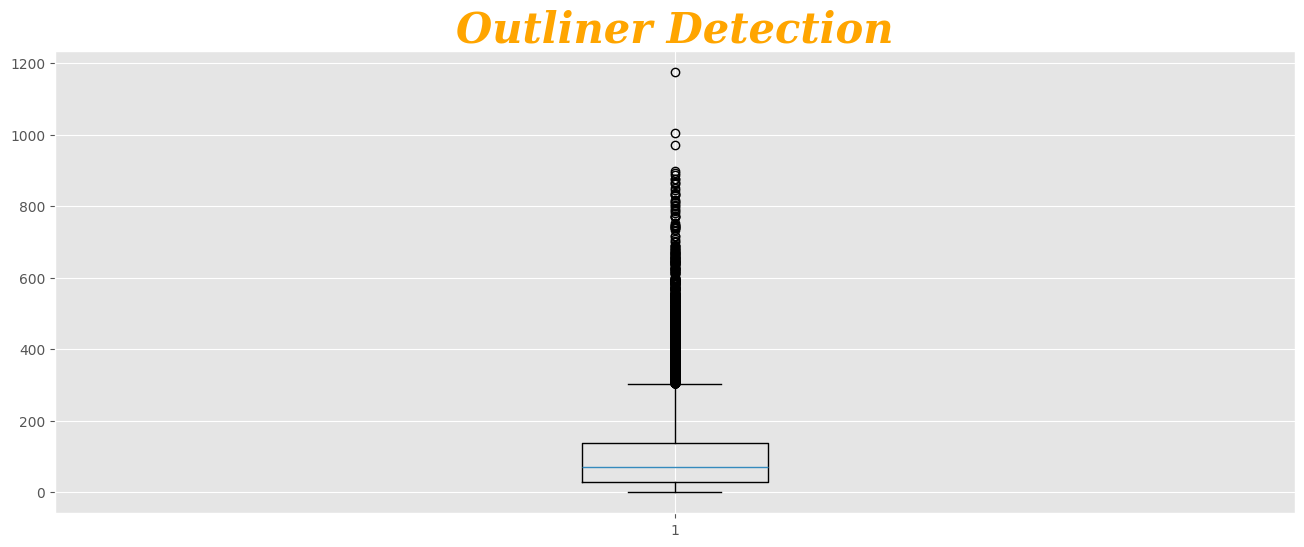

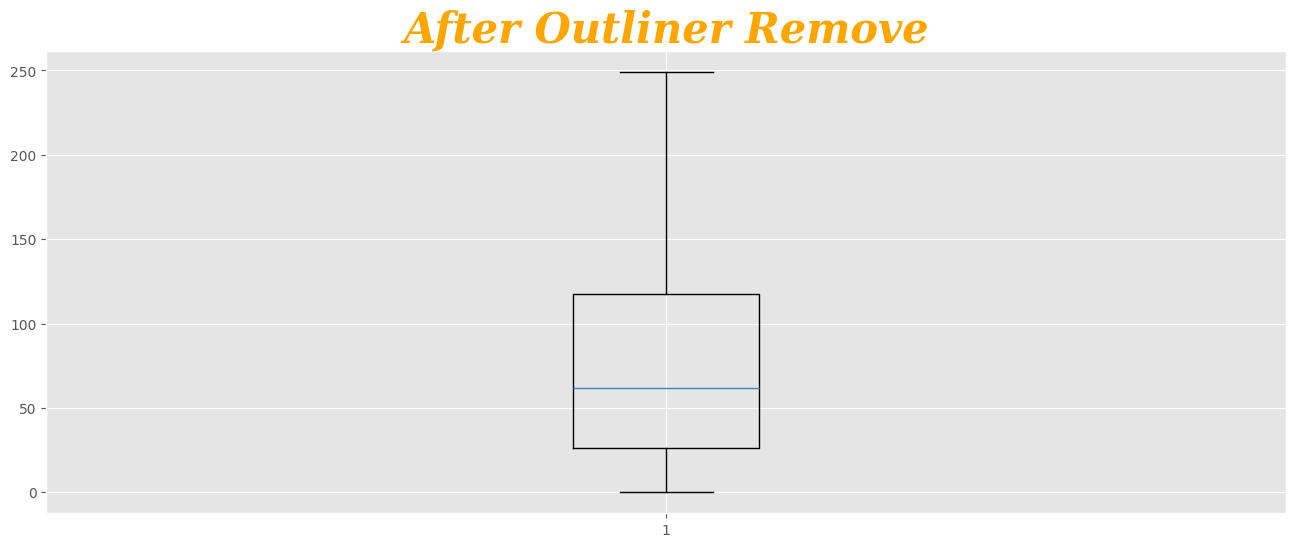

   Transaction_ID    User_ID  Transaction_Amount  Transaction_Type         Timestamp  Account_Balance  Device_Type  Location  Merchant_Category  IP_Address_Flag  Previous_Fraudulent_Activity  Daily_Transaction_Count  Avg_Transaction_Amount_7d  Failed_Transaction_Count_7d  Card_Type  Card_Age  Transaction_Distance  Authentication_Method  Risk_Score  Is_Weekend Fraud_Label
0       TXN_33553  USER_1834               39.79                 3  14/08/2023 19:30         93213.17            0         3                  4                0                             0                        7                     437.63                            3          0        65                883.17                      0      0.8494           0   Not Fraud
1        TXN_9427  USER_7875                1.19                 1   07/06/2023 4:01         75725.25            1         2                  0                0                             0                       13                     478.76          

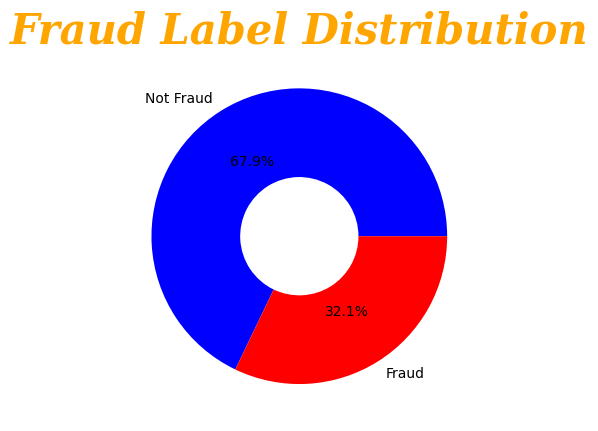



CVS ===  [0.91562466 0.91757286 0.9108308  0.92105263 0.92235755]
Average OF CVS ===  0.9174876984632402


Train Score ==  0.942645870875536
Test Score ==  0.9196810438564698


Accuracy : 
91.96810438564698 %


Confusion matrix : 
[[3765  646]
 [ 462 8922]]


Classification Report : 
              precision    recall  f1-score   support

       Fraud       0.89      0.85      0.87      4411
   Not Fraud       0.93      0.95      0.94      9384

    accuracy                           0.92     13795
   macro avg       0.91      0.90      0.91     13795
weighted avg       0.92      0.92      0.92     13795



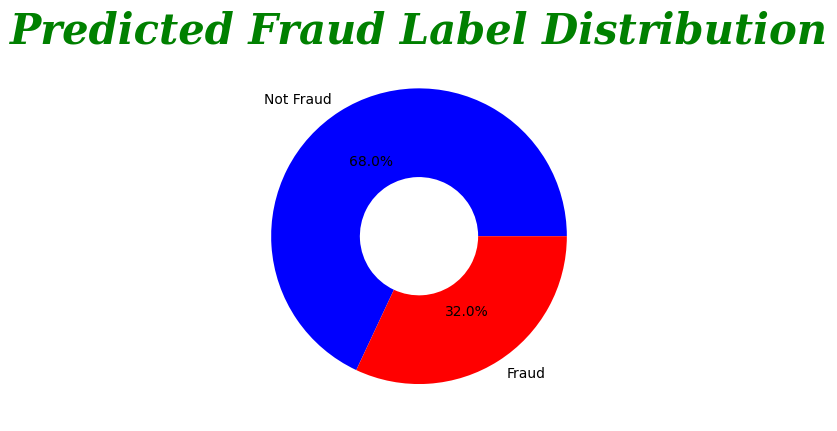

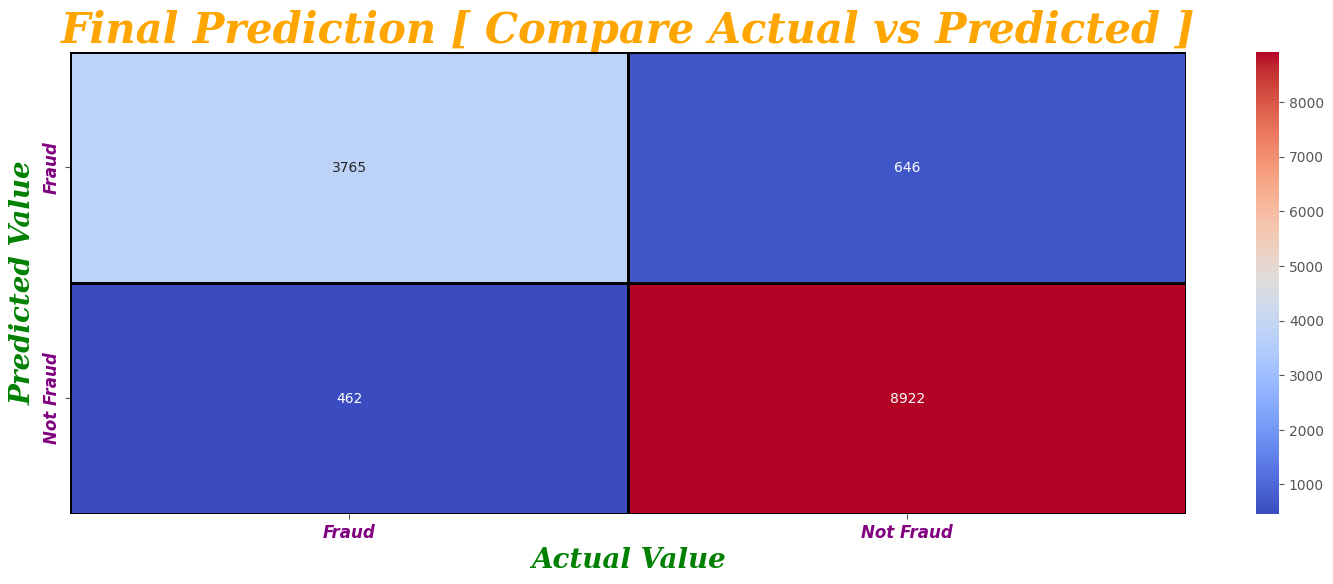

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("synthetic_fraud_dataset.csv")
print(JP.head(30))

print(JP.isnull().sum())
# JP=JP[JP.duplicated()]
# print(JP)

plt.figure(figsize=(16,6))
plt.boxplot(JP['Transaction_Amount'])
plt.title("Outliner Detection",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

Q1=JP['Transaction_Amount'].quantile(0.25)
Q3=JP['Transaction_Amount'].quantile(0.75)

IQR= Q3 - Q1

lower= Q1 - 1.5 * IQR
upper= Q3 + 1.0 * IQR

JP=JP[ ( JP['Transaction_Amount'] > lower) & ( JP['Transaction_Amount'] < upper) ]

plt.figure(figsize=(16,6))
plt.boxplot(JP['Transaction_Amount'])
plt.title("After Outliner Remove",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

from sklearn.preprocessing import LabelEncoder

JP['Transaction_Type']=LabelEncoder().fit_transform(JP['Transaction_Type'])
JP['Device_Type']=LabelEncoder().fit_transform(JP['Device_Type'])
JP['Location']=LabelEncoder().fit_transform(JP['Location'])
JP['Merchant_Category']=LabelEncoder().fit_transform(JP['Merchant_Category'])
JP['Card_Type']=LabelEncoder().fit_transform(JP['Card_Type'])
JP['Authentication_Method']=LabelEncoder().fit_transform(JP['Authentication_Method'])

print(JP.head(20))

print("Number OF Rows & Columns == ",JP.shape)

ABC=JP['Fraud_Label'].value_counts()
print(ABC)

plt.pie(JP['Fraud_Label'].value_counts(),labels=JP['Fraud_Label'].value_counts().index,autopct='%1.1f%%',wedgeprops=dict(width=0.6),colors=['blue','red'])
plt.title("Fraud Label Distribution",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.show()


JP['A']=JP['Transaction_Amount'] * JP['Account_Balance'] * JP['Risk_Score']

x=JP[[
         'Transaction_Amount','Transaction_Type','Account_Balance','Device_Type','Location','Failed_Transaction_Count_7d',  
         'Card_Type','Daily_Transaction_Count','Avg_Transaction_Amount_7d','Authentication_Method','A'  
     ]]
y=JP['Fraud_Label']

from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=10)

score=cross_val_score(model,x,y,cv=5,scoring='accuracy')

print("\n")
print("CVS === ",score)
print("Average OF CVS === ",score.mean())

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=10)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)


# from sklearn.ensemble import RandomForestClassifier

# model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=67)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


# from sklearn.linear_model import LogisticRegression

# model=LogisticRegression()
# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)



from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

Train=model.score(x_train,y_train)
Test=model.score(x_test,y_test)

print("\n")
print("Train Score == ",Train)
print("Test Score == ",Test)

print("\n")
print("Accuracy : ")
print(accuracy_score(y_test,Y_Pred) * 100 , "%")

print("\n")
print("Confusion matrix : ")
CM=confusion_matrix(y_test,Y_Pred)
print(CM)

print("\n")
print("Classification Report : ")
print(classification_report(y_test,Y_Pred))

plt.pie(y_test.value_counts(),labels=y_test.value_counts().index,colors=['blue','red'],autopct='%1.1f%%',wedgeprops=dict(width=0.6))
plt.title("Predicted Fraud Label Distribution",fontsize=30,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

plt.figure(figsize=(18,6))
sns.heatmap(CM,annot=True,fmt='d',cmap='coolwarm',xticklabels=['Fraud','Not Fraud'],yticklabels=['Fraud','Not Fraud'],linewidths=2,linecolor='black')
plt.title("Final Prediction [ Compare Actual vs Predicted ]",fontsize=30,fontweight='bold',color='orange',fontdict={'family':'serif'},fontstyle='italic')
plt.xlabel("Actual Value",fontsize=20,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.ylabel("Predicted Value",fontsize=20,fontweight='bold',color='green',fontdict={'family':'serif'},fontstyle='italic')
plt.xticks(fontsize=12,fontweight='bold',color='purple',fontstyle='italic')
plt.yticks(fontsize=12,fontweight='bold',color='purple',fontstyle='italic')
plt.show()